# Libraries

In [ ]:
import re
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    make_scorer,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score
)

# Get testing dataset VIA API

In [ ]:
EUTILS_BASE = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"
VARIATION_BASE = "https://api.ncbi.nlm.nih.gov/variation/v0"

def clinvar_esearch_ids(term, retmax=5000):
    """
    Search ClinVar and return ClinVar record IDs.
    """
    url = f"{EUTILS_BASE}/esearch.fcgi"
    params = {
        "db": "clinvar",
        "term": term,
        "retmax": retmax,
        "retmode": "json"
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    return data["esearchresult"]["idlist"]

def clinvar_esummary(ids, chunk_size=200):
    """
    Pull ClinVar summaries in JSON.
    """
    all_rows = []
    url = f"{EUTILS_BASE}/esummary.fcgi"

    for i in tqdm(range(0, len(ids), chunk_size), desc="ClinVar esummary"):
        chunk = ids[i:i+chunk_size]
        params = {
            "db": "clinvar",
            "id": ",".join(chunk),
            "retmode": "json"
        }
        r = requests.get(url, params=params, timeout=60)
        r.raise_for_status()
        data = r.json()

        result = data.get("result", {})
        uids = result.get("uids", [])

        for uid in uids:
            item = result.get(uid, {})
            all_rows.append(item)

        time.sleep(0.12)

    return pd.DataFrame(all_rows)

In [ ]:
# Search ClinVar for Alzheimer + Parkinson
alz_term = '("Alzheimer Disease"[Title] OR "Alzheimer disease"[Condition])'
pd_term  = '("Parkinson Disease"[Title] OR "Parkinson disease"[Condition])'

alz_ids = clinvar_esearch_ids(alz_term, retmax=3000)
pd_ids  = clinvar_esearch_ids(pd_term, retmax=3000)

print("ClinVar Alzheimer IDs:", len(alz_ids))
print("ClinVar Parkinson IDs:", len(pd_ids))

ClinVar Alzheimer IDs: 1537
ClinVar Parkinson IDs: 3000


In [ ]:
# Pull summary metadata
alz_sum = clinvar_esummary(alz_ids)
pd_sum  = clinvar_esummary(pd_ids)

alz_sum["disease_label"] = "Alzheimers"
pd_sum["disease_label"]  = "Parkinsons"

clinvar_raw = pd.concat([alz_sum, pd_sum], ignore_index=True)
print(clinvar_raw.shape)
clinvar_raw.head()

ClinVar esummary:   0%|          | 0/8 [00:00<?, ?it/s]

ClinVar esummary:   0%|          | 0/15 [00:00<?, ?it/s]

(4537, 21)


,uid,obj_type,accession,accession_version,title,variation_set,supporting_submissions,germline_classification,clinical_impact_classification,oncogenicity_classification,...,gene_sort,chr_sort,location_sort,variation_set_name,variation_set_id,genes,molecular_consequence_list,protein_change,fda_recognized_database,disease_label
0,4810045,single nucleotide variant,VCV004810045,VCV004810045.1,NM_000484.4(APP):c.2064+11T>C,"[{'measure_id': '4914254', 'variation_xrefs': ...","{'scv': ['SCV007513382'], 'rcv': ['RCV00662807...","{'description': 'Likely benign', 'last_evaluat...","{'description': '', 'last_evaluated': '1/01/01...","{'description': '', 'last_evaluated': '1/01/01...",...,APP,21,00000000000025897562,,,"[{'symbol': 'APP', 'geneid': '351', 'strand': ...",[intron variant],,,Alzheimers
1,4809932,single nucleotide variant,VCV004809932,VCV004809932.1,NM_000447.3(PSEN2):c.142-4A>G,"[{'measure_id': '4914141', 'variation_xrefs': ...","{'scv': ['SCV007513234'], 'rcv': ['RCV00663329...","{'description': 'Likely benign', 'last_evaluat...","{'description': '', 'last_evaluated': '1/01/01...","{'description': '', 'last_evaluated': '1/01/01...",...,PSEN2,01,00000000000226883701,,,"[{'symbol': 'PSEN2', 'geneid': '5664', 'strand...",[intron variant],,,Alzheimers
2,4809004,Microsatellite,VCV004809004,VCV004809004.1,NM_000484.4(APP):c.1990GAG[1] (p.Glu665del),"[{'measure_id': '4921364', 'variation_xrefs': ...","{'scv': ['SCV007512101'], 'rcv': ['RCV00663000...","{'description': 'Uncertain significance', 'las...","{'description': '', 'last_evaluated': '1/01/01...","{'description': '', 'last_evaluated': '1/01/01...",...,APP,21,00000000000025897642,,,"[{'symbol': 'APP', 'geneid': '351', 'strand': ...",[],"E534del, E555del, E572del, E590del, E609del, E...",,Alzheimers
3,4806493,single nucleotide variant,VCV004806493,VCV004806493.1,NM_000447.3(PSEN2):c.854A>G (p.Asn285Ser),"[{'measure_id': '4917136', 'variation_xrefs': ...","{'scv': ['SCV007509270'], 'rcv': ['RCV00661615...","{'description': 'Uncertain significance', 'las...","{'description': '', 'last_evaluated': '1/01/01...","{'description': '', 'last_evaluated': '1/01/01...",...,PSEN2,01,00000000000226890101,,,"[{'symbol': 'PSEN2', 'geneid': '5664', 'strand...",[missense variant],N285S,,Alzheimers
4,4805209,single nucleotide variant,VCV004805209,VCV004805209.1,NM_000447.3(PSEN2):c.1043C>T (p.Pro348Leu),"[{'measure_id': '4913370', 'variation_xrefs': ...","{'scv': ['SCV007507304'], 'rcv': ['RCV00661994...","{'description': 'Uncertain significance', 'las...","{'description': '', 'last_evaluated': '1/01/01...","{'description': '', 'last_evaluated': '1/01/01...",...,PSEN2,01,00000000000226891815,,,"[{'symbol': 'PSEN2', 'geneid': '5664', 'strand...",[missense variant],"P347L, P348L",,Alzheimers


In [ ]:
clinvar_raw = clinvar_raw[[
    "chr_sort",
    "location_sort",
    "gene_sort",
    "disease_label"
]]

In [ ]:
# drop exact duplicates
clinvar_raw = clinvar_raw.drop_duplicates().copy()

# convert position to numeric
clinvar_raw["location_sort"] = pd.to_numeric(clinvar_raw["location_sort"], errors="coerce")

# remove rows missing essential fields
clinvar_raw = clinvar_raw.dropna(subset=["chr_sort", "location_sort", "gene_sort", "disease_label"]).copy()

# standardize text columns
clinvar_raw["chr_sort"] = clinvar_raw["chr_sort"].astype(str).str.strip()
clinvar_raw["gene_sort"] = clinvar_raw["gene_sort"].astype(str).str.strip()
clinvar_raw["disease_label"] = clinvar_raw["disease_label"].astype(str).str.strip()

print(clinvar_raw.shape)

(4264, 4)


In [ ]:
# match schema to GWAS dataset
clinvar = clinvar_raw.rename(columns={
    "chr_sort": "chr",
    "location_sort": "pos",
    "gene_sort": "mapped_gene"
}).copy()

print(clinvar.head())

  chr          pos mapped_gene disease_label
0  21   25897000.0         APP    Alzheimers
1  01  226883000.0       PSEN2    Alzheimers
2  21   25897000.0         APP    Alzheimers
3  01  226890000.0       PSEN2    Alzheimers
4  01  226891000.0       PSEN2    Alzheimers


# Models

In [ ]:
url = "https://raw.githubusercontent.com/naomi-rlm/Alzheimer-s_vs_Parkinson-s_Group10/main/Data/Alz_Pd_Clean.csv"

Alz_Pd_Clean = pd.read_csv(url)
print(Alz_Pd_Clean.head())
print(Alz_Pd_Clean["disease_label"].value_counts())

  disease_label effect_allele       p_value  eaf  odds_ratio  beta  \
0    Alzheimers    rs757278-T  3.000000e-06  NaN         NaN   NaN   
1    Alzheimers  rs55889290-A  4.000000e-07  NaN         NaN   NaN   
2    Alzheimers  rs11903348-C  7.000000e-07  NaN         NaN   NaN   
3    Alzheimers  rs28531854-A  4.000000e-06  NaN         NaN   NaN   
4    Alzheimers  rs67919177-T  3.000000e-06  NaN         NaN   NaN   

         mapped_gene                   reported_trait study_accession  \
0            CTTNBP2  Early-onset Alzheimer's disease    GCST90558102   
1              CES5A  Early-onset Alzheimer's disease    GCST90558102   
2  RPL38P2,LINC01851  Early-onset Alzheimer's disease    GCST90558102   
3        COL6A3,MLPH  Early-onset Alzheimer's disease    GCST90558102   
4   DPY19L2,RPS27P24  Early-onset Alzheimer's disease    GCST90558102   

   pubmed_id    locations author chr          pos  variant_key  p_invalid  \
0   39023044  7:117737591  Ge YJ   7  117737591.0  7:117737591 

In [ ]:
# Only keep columns for training
GWAS = Alz_Pd_Clean[["chr", "pos", "mapped_gene", "disease_label"]]
GWAS = GWAS.dropna(subset=["chr", "pos", "mapped_gene", "disease_label"])
print(GWAS.head())
print(GWAS["disease_label"].value_counts())

  chr          pos        mapped_gene disease_label
0   7  117737591.0            CTTNBP2    Alzheimers
1  16   55912846.0              CES5A    Alzheimers
2   2   77855346.0  RPL38P2,LINC01851    Alzheimers
3   2  237464057.0        COL6A3,MLPH    Alzheimers
4  12   63711968.0   DPY19L2,RPS27P24    Alzheimers
disease_label
Alzheimers    5127
Parkinsons     744
Name: count, dtype: int64


In [ ]:
# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parkinsons is smaller so F1 as the tuning objective
parkinsons_f1 = make_scorer(f1_score, pos_label="Parkinsons")

## Logistic Regression

### GWAS

In [ ]:
# features and target
X = GWAS[["chr", "pos", "mapped_gene"]]
y = GWAS["disease_label"]

# stratified split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# preprocess numeric and categorical columns
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["pos"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["chr", "mapped_gene"])
])

# logistic regression pipeline
log_reg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

# train model
log_reg_model.fit(X_train, y_train)

# validation score
print("Validation accuracy:", log_reg_model.score(X_val, y_val))

Validation accuracy: 0.8587234042553191


In [ ]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

log_reg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"],
    "classifier__solver": ["lbfgs", "liblinear"]
}

log_reg_search = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=log_reg_param_grid,
    scoring=parkinsons_f1,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

log_reg_search.fit(X_train, y_train)

log_reg_model = log_reg_search.best_estimator_

print("Best Logistic Regression params:", log_reg_search.best_params_)
print("Best Logistic Regression CV Parkinsons F1:", log_reg_search.best_score_)
print("Validation accuracy:", log_reg_model.score(X_val, y_val))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Logistic Regression params: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}
Best Logistic Regression CV Parkinsons F1: 0.6593471619833542
Validation accuracy: 0.9259574468085107


In [ ]:
# validation predictions
y_pred = log_reg_model.predict(X_val)
y_proba = log_reg_model.predict_proba(X_val)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# make sure the positive class is Parkinsons
y_val_binary = (y_val == "Parkinsons").astype(int)

print("ROC AUC:", roc_auc_score(y_val_binary, y_proba))
print("Average Precision:", average_precision_score(y_val_binary, y_proba))

Confusion Matrix:
[[1011   15]
 [  72   77]]

Classification Report:
              precision    recall  f1-score   support

  Alzheimers       0.93      0.99      0.96      1026
  Parkinsons       0.84      0.52      0.64       149

    accuracy                           0.93      1175
   macro avg       0.89      0.75      0.80      1175
weighted avg       0.92      0.93      0.92      1175

ROC AUC: 0.8523522639559376
Average Precision: 0.6483542765568249


### CliniVar

In [ ]:
# features and target
X_clinvar = clinvar[["chr", "pos", "mapped_gene"]]
y_clinvar = clinvar["disease_label"]

# test model on ClinVar data
y_clinvar_pred = log_reg_model.predict(X_clinvar)
y_clinvar_proba = log_reg_model.predict_proba(X_clinvar)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_clinvar, y_clinvar_pred))

print("\nClassification Report:")
print(classification_report(y_clinvar, y_clinvar_pred))

# make sure the positive class is Parkinsons
y_clinvar_binary = (y_clinvar == "Parkinsons").astype(int)

print("ROC AUC:", roc_auc_score(y_clinvar_binary, y_clinvar_proba))
print("Average Precision:", average_precision_score(y_clinvar_binary, y_clinvar_proba))

Confusion Matrix:
[[1393   39]
 [2218  614]]

Classification Report:
              precision    recall  f1-score   support

  Alzheimers       0.39      0.97      0.55      1432
  Parkinsons       0.94      0.22      0.35      2832

    accuracy                           0.47      4264
   macro avg       0.66      0.59      0.45      4264
weighted avg       0.75      0.47      0.42      4264

ROC AUC: 0.4984662516175867
Average Precision: 0.700355033674923


## Random Forest

### GWAS

In [ ]:
# random forest model
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ))
])

# train model
rf_model.fit(X_train, y_train)

# validation score
print("Validation accuracy:", rf_model.score(X_val, y_val))

Validation accuracy: 0.934468085106383


In [ ]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__class_weight": ["balanced"]
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring=parkinsons_f1,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

rf_model = rf_search.best_estimator_

print("Best Random Forest params:", rf_search.best_params_)
print("Best Random Forest CV Parkinsons F1:", rf_search.best_score_)
print("Validation accuracy:", rf_model.score(X_val, y_val))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Random Forest params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best Random Forest CV Parkinsons F1: 0.6992625304005295
Validation accuracy: 0.9319148936170213


In [ ]:
# validation predictions
y_pred_rf = rf_model.predict(X_val)
y_proba_rf = rf_model.predict_proba(X_val)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf))

# make sure the positive class is Parkinsons
y_val_binary = (y_val == "Parkinsons").astype(int)

print("ROC AUC:", roc_auc_score(y_val_binary, y_proba_rf))
print("Average Precision:", average_precision_score(y_val_binary, y_proba_rf))

Confusion Matrix:
[[1016   10]
 [  70   79]]

Classification Report:
              precision    recall  f1-score   support

  Alzheimers       0.94      0.99      0.96      1026
  Parkinsons       0.89      0.53      0.66       149

    accuracy                           0.93      1175
   macro avg       0.91      0.76      0.81      1175
weighted avg       0.93      0.93      0.92      1175

ROC AUC: 0.8627595274539818
Average Precision: 0.6837193482324033


### Clinivar

In [ ]:
# ClinVar features and target
X_clinvar = clinvar[["chr", "pos", "mapped_gene"]]
y_clinvar = clinvar["disease_label"]

# ClinVar predictions
y_clinvar_pred_rf = rf_model.predict(X_clinvar)
y_clinvar_proba_rf = rf_model.predict_proba(X_clinvar)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_clinvar, y_clinvar_pred_rf))

print("\nClassification Report:")
print(classification_report(y_clinvar, y_clinvar_pred_rf))

# make sure the positive class is Parkinsons
y_clinvar_binary = (y_clinvar == "Parkinsons").astype(int)

print("ROC AUC:", roc_auc_score(y_clinvar_binary, y_clinvar_proba_rf))
print("Average Precision:", average_precision_score(y_clinvar_binary, y_clinvar_proba_rf))

Confusion Matrix:
[[1407   25]
 [2276  556]]

Classification Report:
              precision    recall  f1-score   support

  Alzheimers       0.38      0.98      0.55      1432
  Parkinsons       0.96      0.20      0.33      2832

    accuracy                           0.46      4264
   macro avg       0.67      0.59      0.44      4264
weighted avg       0.76      0.46      0.40      4264

ROC AUC: 0.609088716740839
Average Precision: 0.7685877301447629


## Gradient Boosting

### GWAS

In [ ]:
# gradient boosting model
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

# train model
gb_model.fit(X_train, y_train)

# validation score
print("Validation accuracy:", gb_model.score(X_val, y_val))

Validation accuracy: 0.8902127659574468


In [ ]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3],
    "classifier__subsample": [0.8, 1.0]
}

gb_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring=parkinsons_f1,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

gb_model = gb_search.best_estimator_

print("Best Gradient Boosting params:", gb_search.best_params_)
print("Best Gradient Boosting CV Parkinsons F1:", gb_search.best_score_)
print("Validation accuracy:", gb_model.score(X_val, y_val))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Gradient Boosting params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Best Gradient Boosting CV Parkinsons F1: 0.4309924596403184
Validation accuracy: 0.9063829787234042


In [ ]:
# validation predictions
y_pred_gb = gb_model.predict(X_val)
y_proba_gb = gb_model.predict_proba(X_val)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_gb))

# make sure the positive class is Parkinsons
y_val_binary = (y_val == "Parkinsons").astype(int)

print("ROC AUC:", roc_auc_score(y_val_binary, y_proba_gb))
print("Average Precision:", average_precision_score(y_val_binary, y_proba_gb))

Confusion Matrix:
[[1021    5]
 [ 105   44]]

Classification Report:
              precision    recall  f1-score   support

  Alzheimers       0.91      1.00      0.95      1026
  Parkinsons       0.90      0.30      0.44       149

    accuracy                           0.91      1175
   macro avg       0.90      0.65      0.70      1175
weighted avg       0.91      0.91      0.88      1175

ROC AUC: 0.8082080667739446
Average Precision: 0.6010700225711312


### CliniVar

In [ ]:
# ClinVar features and target
X_clinvar = clinvar[["chr", "pos", "mapped_gene"]]
y_clinvar = clinvar["disease_label"]

# ClinVar predictions
y_clinvar_pred_gb = gb_model.predict(X_clinvar)
y_clinvar_proba_gb = gb_model.predict_proba(X_clinvar)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_clinvar, y_clinvar_pred_gb))

print("\nClassification Report:")
print(classification_report(y_clinvar, y_clinvar_pred_gb))

# make sure the positive class is Parkinsons
y_clinvar_binary = (y_clinvar == "Parkinsons").astype(int)

print("ROC AUC:", roc_auc_score(y_clinvar_binary, y_clinvar_proba_gb))
print("Average Precision:", average_precision_score(y_clinvar_binary, y_clinvar_proba_gb))

Confusion Matrix:
[[1407   25]
 [2309  523]]

Classification Report:
              precision    recall  f1-score   support

  Alzheimers       0.38      0.98      0.55      1432
  Parkinsons       0.95      0.18      0.31      2832

    accuracy                           0.45      4264
   macro avg       0.67      0.58      0.43      4264
weighted avg       0.76      0.45      0.39      4264

ROC AUC: 0.6567832364753969
Average Precision: 0.8033268670975734


## K-Nearest Neighbors

### GWAS

In [ ]:
# KNN model
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

# train model
knn_model.fit(X_train, y_train)

# validation score
print("Validation accuracy:", knn_model.score(X_val, y_val))

Validation accuracy: 0.9004255319148936


In [ ]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 11, 15],
    "classifier__weights": ["uniform", "distance"],
    "classifier__p": [1, 2]
}

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring=parkinsons_f1,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

knn_search.fit(X_train, y_train)

knn_model = knn_search.best_estimator_

print("Best KNN params:", knn_search.best_params_)
print("Best KNN CV Parkinsons F1:", knn_search.best_score_)
print("Validation accuracy:", knn_model.score(X_val, y_val))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.65248403 0.61489017 0.65248403        nan 0.657112
 0.59174153 0.65648504        nan 0.65721251 0.57668069 0.65721251
        nan 0.65016928 0.52900526 0.65080604        nan 0.66314409
 0.49630306 0.6637399 ]
  warnings.warn(


Best KNN params: {'classifier__n_neighbors': 15, 'classifier__p': 2, 'classifier__weights': 'distance'}
Best KNN CV Parkinsons F1: 0.6637398962241665
Validation accuracy: 0.916595744680851


In [ ]:
# validation predictions
y_pred_knn = knn_model.predict(X_val)
y_proba_knn = knn_model.predict_proba(X_val)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_knn))

# make sure the positive class is Parkinsons
y_val_binary = (y_val == "Parkinsons").astype(int)

print("ROC AUC:", roc_auc_score(y_val_binary, y_proba_knn))
print("Average Precision:", average_precision_score(y_val_binary, y_proba_knn))

Confusion Matrix:
[[993  33]
 [ 65  84]]

Classification Report:
              precision    recall  f1-score   support

  Alzheimers       0.94      0.97      0.95      1026
  Parkinsons       0.72      0.56      0.63       149

    accuracy                           0.92      1175
   macro avg       0.83      0.77      0.79      1175
weighted avg       0.91      0.92      0.91      1175

ROC AUC: 0.8580922851498618
Average Precision: 0.6844991987782635


### CliniVar

In [ ]:
# ClinVar features and target
X_clinvar = clinvar[["chr", "pos", "mapped_gene"]]
y_clinvar = clinvar["disease_label"]

# ClinVar predictions
y_clinvar_pred_knn = knn_model.predict(X_clinvar)
y_clinvar_proba_knn = knn_model.predict_proba(X_clinvar)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_clinvar, y_clinvar_pred_knn))

print("\nClassification Report:")
print(classification_report(y_clinvar, y_clinvar_pred_knn))

# make sure the positive class is Parkinsons
y_clinvar_binary = (y_clinvar == "Parkinsons").astype(int)

print("ROC AUC:", roc_auc_score(y_clinvar_binary, y_clinvar_proba_knn))
print("Average Precision:", average_precision_score(y_clinvar_binary, y_clinvar_proba_knn))

Confusion Matrix:
[[1405   27]
 [2213  619]]

Classification Report:
              precision    recall  f1-score   support

  Alzheimers       0.39      0.98      0.56      1432
  Parkinsons       0.96      0.22      0.36      2832

    accuracy                           0.47      4264
   macro avg       0.67      0.60      0.46      4264
weighted avg       0.77      0.47      0.42      4264

ROC AUC: 0.5339976781712591
Average Precision: 0.7335570057146077


## Summary Table

In [ ]:
# models to compare
model_dict = {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "KNN": knn_model
}

results = []

for model_name, model in model_dict.items():
    # GWAS validation metrics
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    y_val_binary = (y_val == "Parkinsons").astype(int)

    gwas_accuracy = accuracy_score(y_val, y_val_pred)
    gwas_precision = precision_score(y_val, y_val_pred, pos_label="Parkinsons", zero_division=0)
    gwas_recall = recall_score(y_val, y_val_pred, pos_label="Parkinsons", zero_division=0)
    gwas_f1 = f1_score(y_val, y_val_pred, pos_label="Parkinsons", zero_division=0)
    gwas_roc_auc = roc_auc_score(y_val_binary, y_val_proba)
    gwas_pr_auc = average_precision_score(y_val_binary, y_val_proba)

    # ClinVar external metrics
    y_clinvar_pred = model.predict(X_clinvar)
    y_clinvar_proba = model.predict_proba(X_clinvar)[:, 1]
    y_clinvar_binary = (y_clinvar == "Parkinsons").astype(int)

    clinvar_accuracy = accuracy_score(y_clinvar, y_clinvar_pred)
    clinvar_precision = precision_score(y_clinvar, y_clinvar_pred, pos_label="Parkinsons", zero_division=0)
    clinvar_recall = recall_score(y_clinvar, y_clinvar_pred, pos_label="Parkinsons", zero_division=0)
    clinvar_f1 = f1_score(y_clinvar, y_clinvar_pred, pos_label="Parkinsons", zero_division=0)
    clinvar_roc_auc = roc_auc_score(y_clinvar_binary, y_clinvar_proba)
    clinvar_pr_auc = average_precision_score(y_clinvar_binary, y_clinvar_proba)

    results.append({
        "Model": model_name,
        "GWAS Accuracy": gwas_accuracy,
        "GWAS Parkinsons Precision": gwas_precision,
        "GWAS Parkinsons Recall": gwas_recall,
        "GWAS Parkinsons F1": gwas_f1,
        "GWAS ROC-AUC": gwas_roc_auc,
        "GWAS PR-AUC": gwas_pr_auc,
        "ClinVar Accuracy": clinvar_accuracy,
        "ClinVar Parkinsons Precision": clinvar_precision,
        "ClinVar Parkinsons Recall": clinvar_recall,
        "ClinVar Parkinsons F1": clinvar_f1,
        "ClinVar ROC-AUC": clinvar_roc_auc,
        "ClinVar PR-AUC": clinvar_pr_auc
    })

comparison_df = pd.DataFrame(results)

# sort by external Parkinsons F1, since external generalization matters most
comparison_df = comparison_df.sort_values(by="ClinVar Parkinsons F1", ascending=False)

# round for readability
comparison_df = comparison_df.round(3)

comparison_df

,Model,GWAS Accuracy,GWAS Parkinsons Precision,GWAS Parkinsons Recall,GWAS Parkinsons F1,GWAS ROC-AUC,GWAS PR-AUC,ClinVar Accuracy,ClinVar Parkinsons Precision,ClinVar Parkinsons Recall,ClinVar Parkinsons F1,ClinVar ROC-AUC,ClinVar PR-AUC
3,KNN,0.917,0.718,0.564,0.632,0.858,0.684,0.475,0.958,0.219,0.356,0.534,0.734
0,Logistic Regression,0.926,0.837,0.517,0.639,0.852,0.648,0.471,0.940,0.217,0.352,0.498,0.700
1,Random Forest,0.932,0.888,0.530,0.664,0.863,0.684,0.460,0.957,0.196,0.326,0.609,0.769
2,Gradient Boosting,0.906,0.898,0.295,0.444,0.808,0.601,0.453,0.954,0.185,0.309,0.657,0.803


## Visualizations

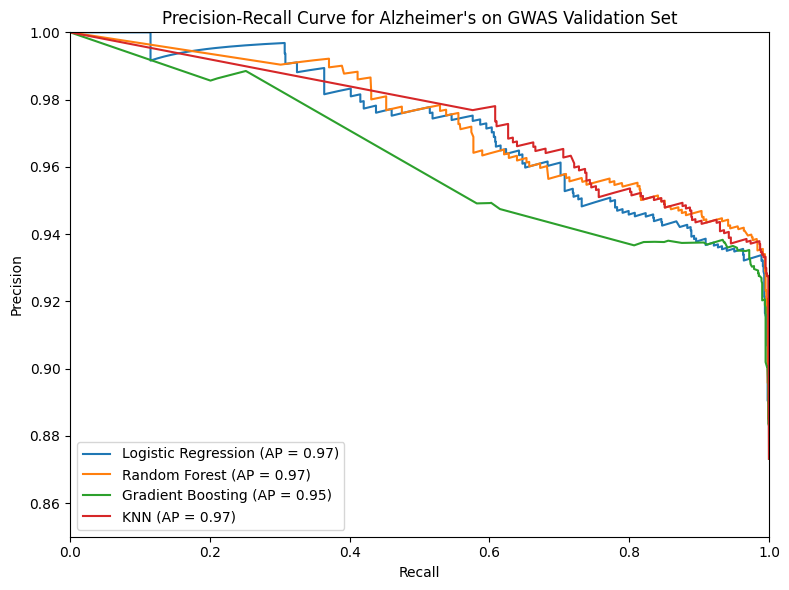

In [ ]:
# GWAS Alzheimer's PR curve
y_gwas_alz = (y_val == "Alzheimers").astype(int)

plt.figure(figsize=(8, 6))

for name, model in {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "KNN": knn_model
}.items():
    class_index = list(model.classes_).index("Alzheimers")
    y_proba = model.predict_proba(X_val)[:, class_index]
    precision, recall, _ = precision_recall_curve(y_gwas_alz, y_proba)
    ap = average_precision_score(y_gwas_alz, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Alzheimer's on GWAS Validation Set")
plt.xlim(0, 1)
plt.ylim(0.85, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

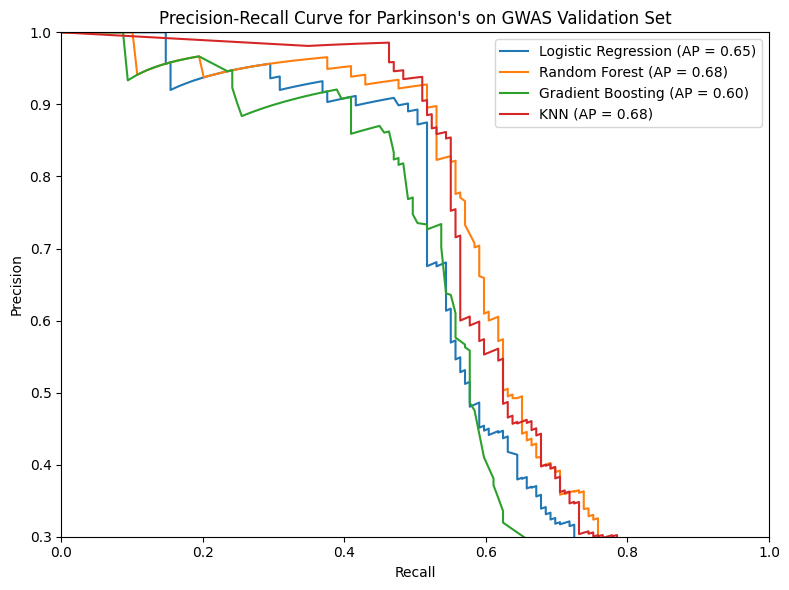

In [ ]:
# GWAS Parkinson's PR curve

y_gwas_pd = (y_val == "Parkinsons").astype(int)

plt.figure(figsize=(8, 6))

for name, model in {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "KNN": knn_model
}.items():
    class_index = list(model.classes_).index("Parkinsons")
    y_proba = model.predict_proba(X_val)[:, class_index]
    precision, recall, _ = precision_recall_curve(y_gwas_pd, y_proba)
    ap = average_precision_score(y_gwas_pd, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Parkinson's on GWAS Validation Set")
plt.xlim(0, 1)
plt.ylim(0.3, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

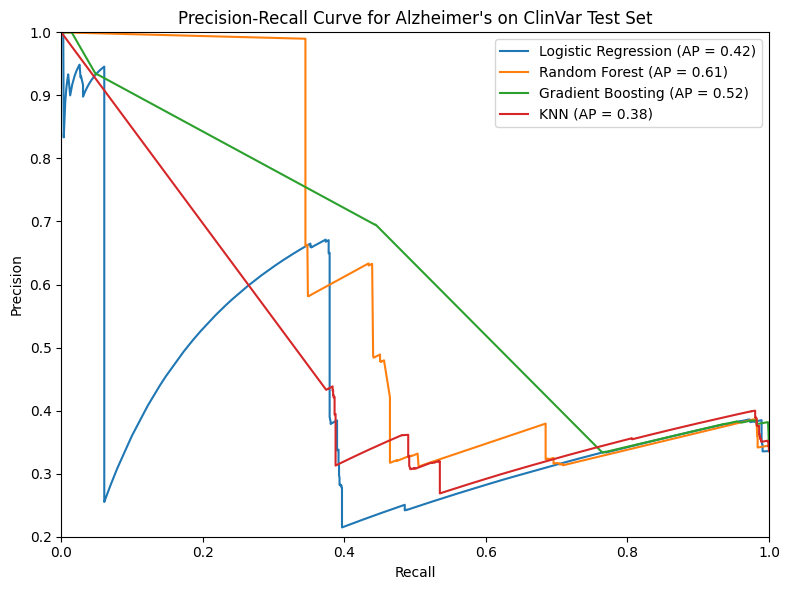

In [ ]:
# ClinVar Alzheimer's PR curve

X_clinvar = clinvar[["chr", "pos", "mapped_gene"]]
y_clinvar_alz = (clinvar["disease_label"] == "Alzheimers").astype(int)

plt.figure(figsize=(8, 6))

for name, model in {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "KNN": knn_model
}.items():
    class_index = list(model.classes_).index("Alzheimers")
    y_proba = model.predict_proba(X_clinvar)[:, class_index]
    precision, recall, _ = precision_recall_curve(y_clinvar_alz, y_proba)
    ap = average_precision_score(y_clinvar_alz, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Alzheimer's on ClinVar Test Set")
plt.xlim(0, 1)
plt.ylim(0.2, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

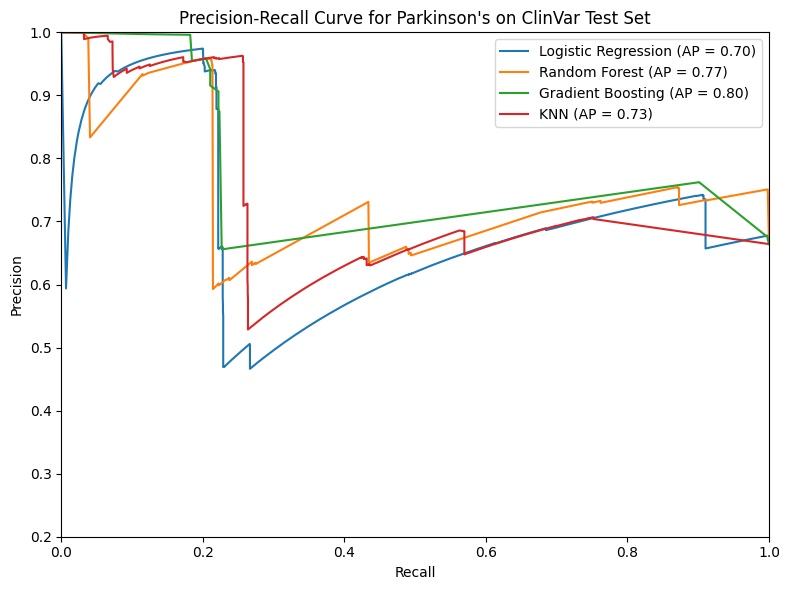

In [ ]:
# ClinVar Parkinson's PR curve

X_clinvar = clinvar[["chr", "pos", "mapped_gene"]]
y_clinvar_pd = (clinvar["disease_label"] == "Parkinsons").astype(int)

plt.figure(figsize=(8, 6))

for name, model in {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "KNN": knn_model
}.items():
    class_index = list(model.classes_).index("Parkinsons")
    y_proba = model.predict_proba(X_clinvar)[:, class_index]
    precision, recall, _ = precision_recall_curve(y_clinvar_pd, y_proba)
    ap = average_precision_score(y_clinvar_pd, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Parkinson's on ClinVar Test Set")
plt.xlim(0, 1)
plt.ylim(0.2, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance for Random Forest on validation set

In [ ]:
# aggregate Random Forest feature importances back to original feature groups
rf_classifier = rf_model.named_steps["classifier"]
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance_df["group"] = feature_importance_df["feature"].apply(
    lambda x: "pos" if "num__pos" in x
    else "chr" if "cat__chr_" in x
    else "mapped_gene" if "cat__mapped_gene_" in x
    else "other"
)

group_importance_df = (
    feature_importance_df
    .groupby("group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

print(group_importance_df)

         group  importance
1  mapped_gene    0.689450
0          chr    0.160596
2          pos    0.149954


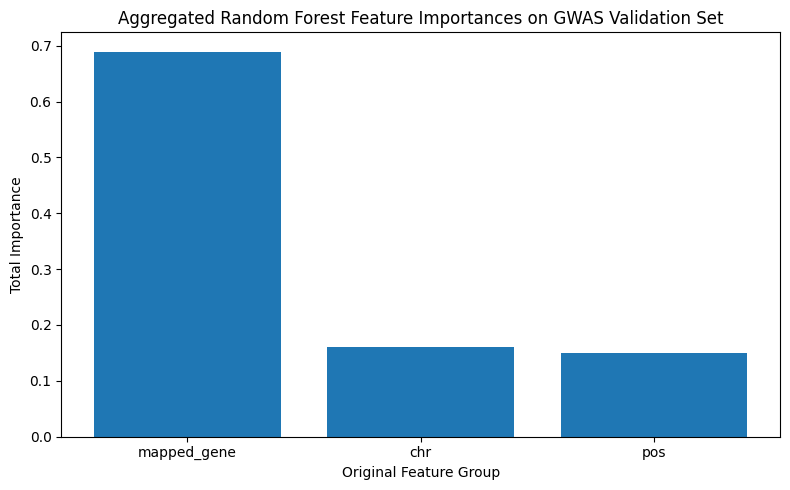

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(group_importance_df["group"], group_importance_df["importance"])
plt.xlabel("Original Feature Group")
plt.ylabel("Total Importance")
plt.title("Aggregated Random Forest Feature Importances on GWAS Validation Set")
plt.tight_layout()
plt.show()

                gene  importance
2315            SNCA    0.015731
2017            RIT2    0.007735
614             DLG2    0.007573
1397           LRRK2    0.006893
2239          SH3GL2    0.006685
832             GCH1    0.006556
273             BST1    0.006249
1632         NECTIN2    0.005541
1449           MCCC1    0.005311
1287  LINC02349,RORA    0.004922


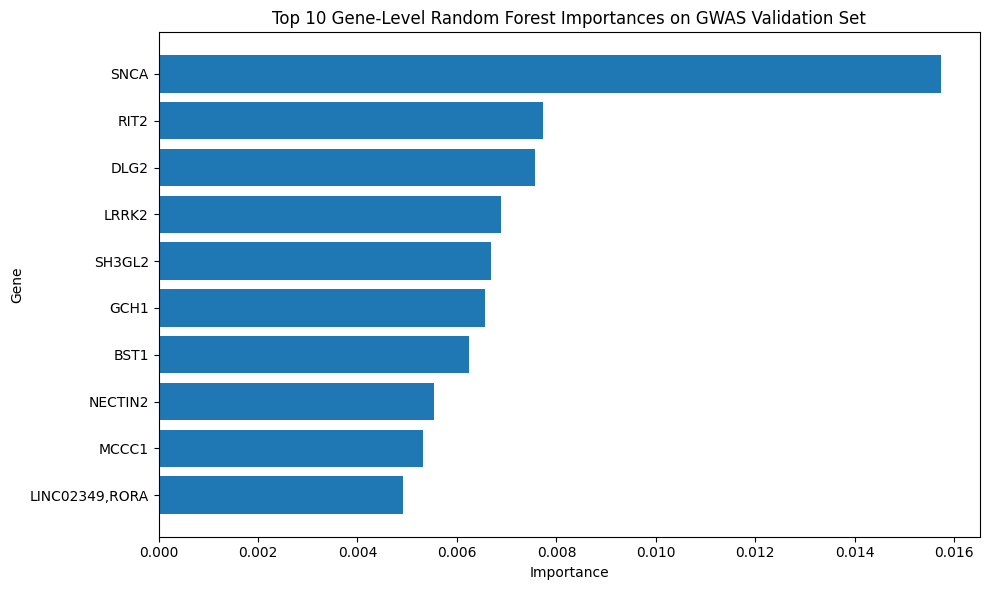

In [ ]:
# top 10 gene level feature importances from Random Forest

gene_importance_df = feature_importance_df[
    feature_importance_df["feature"].str.contains("cat__mapped_gene_")
].copy()

gene_importance_df["gene"] = gene_importance_df["feature"].str.replace("cat__mapped_gene_", "", regex=False)

top_gene_importance_df = gene_importance_df.sort_values("importance", ascending=False).head(10)

print(top_gene_importance_df[["gene", "importance"]])

plt.figure(figsize=(10, 6))
plt.barh(top_gene_importance_df["gene"], top_gene_importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Gene")
plt.title("Top 10 Gene-Level Random Forest Importances on GWAS Validation Set")
plt.tight_layout()
plt.show()

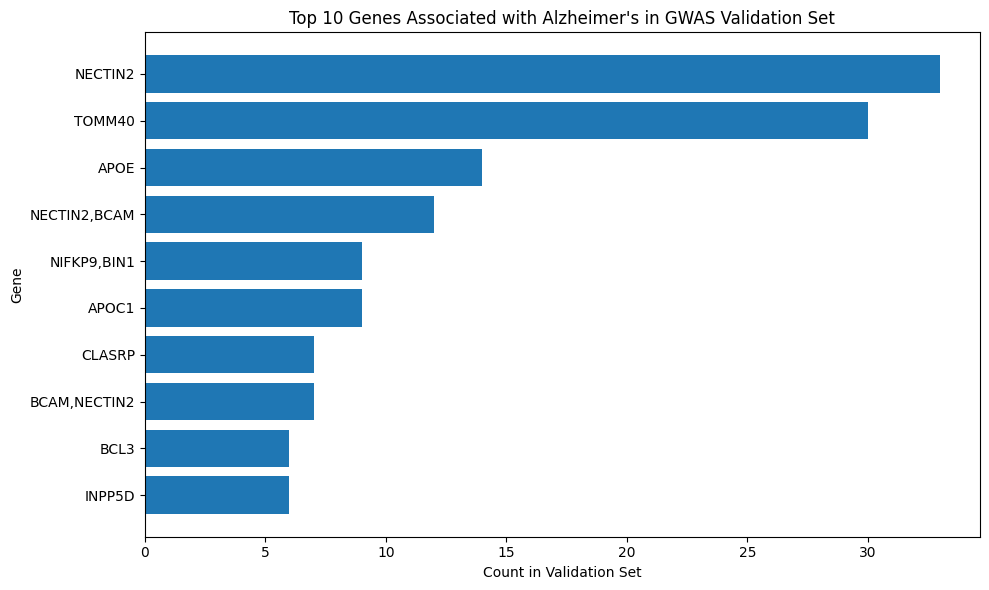

In [ ]:
alz_data = X_val.copy()
alz_data["label"] = y_val.values

alz_genes = (
    alz_data[alz_data["label"] == "Alzheimers"]["mapped_gene"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))
plt.barh(alz_genes.index, alz_genes.values)
plt.gca().invert_yaxis()
plt.xlabel("Count in Validation Set")
plt.ylabel("Gene")
plt.title("Top 10 Genes Associated with Alzheimer's in GWAS Validation Set")
plt.tight_layout()
plt.show()

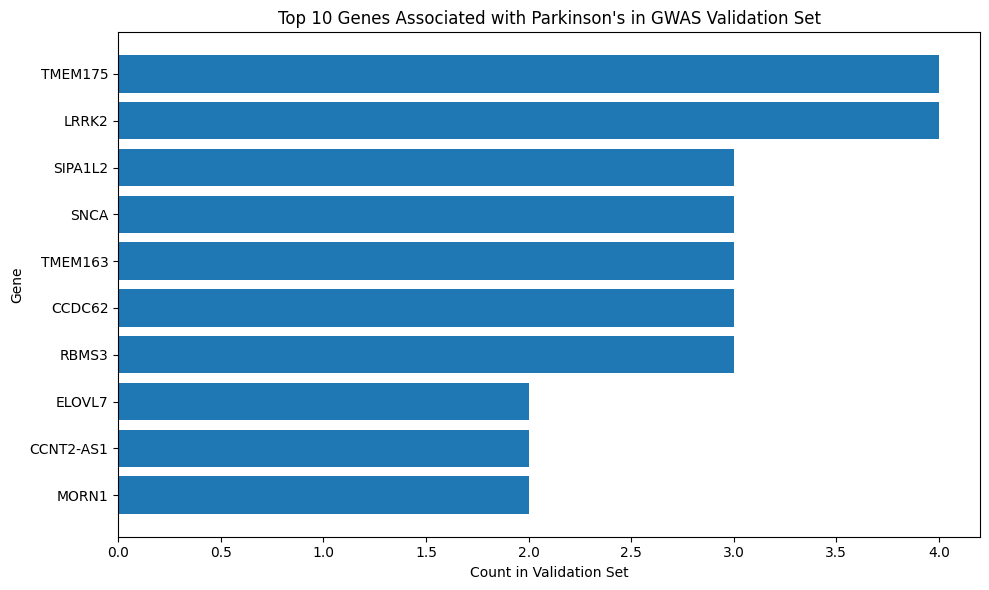

In [ ]:
pd_data = X_val.copy()
pd_data["label"] = y_val.values

pd_genes = (
    pd_data[pd_data["label"] == "Parkinsons"]["mapped_gene"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))
plt.barh(pd_genes.index, pd_genes.values)
plt.gca().invert_yaxis()
plt.xlabel("Count in Validation Set")
plt.ylabel("Gene")
plt.title("Top 10 Genes Associated with Parkinson's in GWAS Validation Set")
plt.tight_layout()
plt.show()

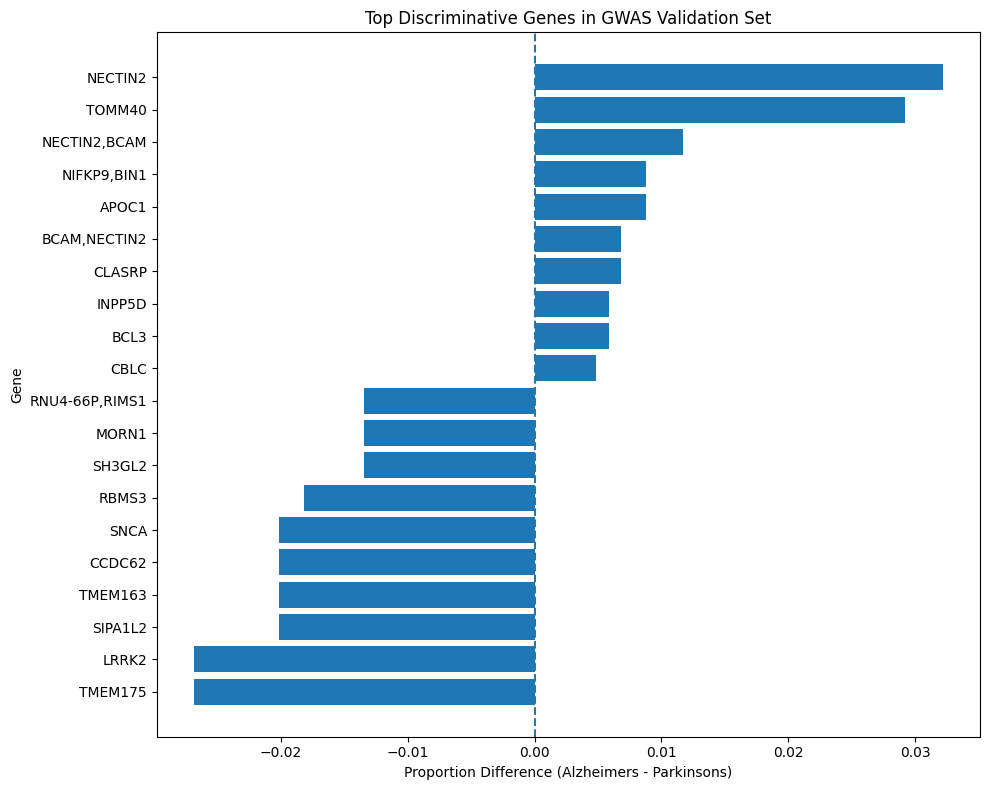

In [ ]:
# combine validation features and labels
val_gene_df = X_val.copy()
val_gene_df["disease_label"] = y_val.values

# count genes by disease
gene_counts = (
    val_gene_df.groupby(["mapped_gene", "disease_label"])
    .size()
    .unstack(fill_value=0)
)

# convert to within-disease proportions
gene_props = gene_counts.div(gene_counts.sum(axis=0), axis=1)

# make sure both columns exist
if "Alzheimers" not in gene_props.columns:
    gene_props["Alzheimers"] = 0
if "Parkinsons" not in gene_props.columns:
    gene_props["Parkinsons"] = 0

# discriminative score: positive = more Alzheimer's, negative = more Parkinson's
gene_props["diff"] = gene_props["Alzheimers"] - gene_props["Parkinsons"]

# top 10 for each side
top_alz = gene_props.sort_values("diff", ascending=False).head(10)
top_pd = gene_props.sort_values("diff", ascending=True).head(10)

# combine for plotting
plot_df = pd.concat([top_alz, top_pd]).sort_values("diff")

plt.figure(figsize=(10, 8))
plt.barh(plot_df.index, plot_df["diff"])
plt.axvline(0, linestyle="--")
plt.xlabel("Proportion Difference (Alzheimers - Parkinsons)")
plt.ylabel("Gene")
plt.title("Top Discriminative Genes in GWAS Validation Set")
plt.tight_layout()
plt.show()

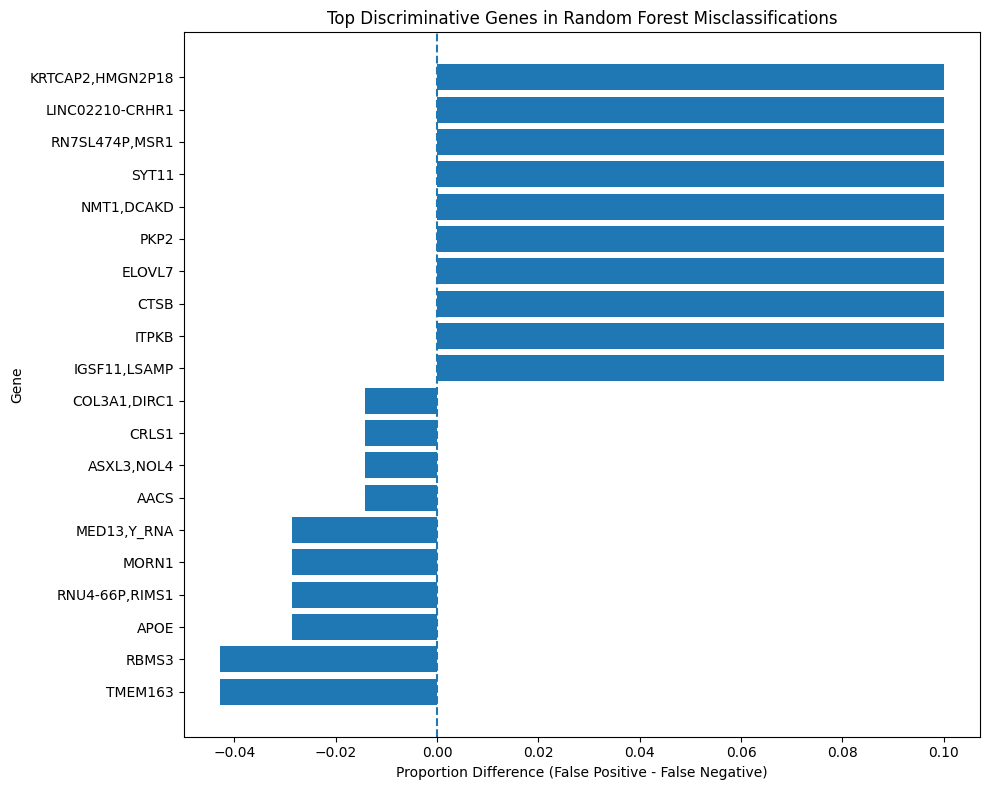

In [ ]:
# build validation results dataframe
error_gene_df = X_val.copy()
error_gene_df["true_label"] = y_val.values
error_gene_df["pred_label"] = y_pred_rf

# keep only false positives and false negatives
error_gene_df = error_gene_df[
    ((error_gene_df["true_label"] == "Alzheimers") & (error_gene_df["pred_label"] == "Parkinsons")) |
    ((error_gene_df["true_label"] == "Parkinsons") & (error_gene_df["pred_label"] == "Alzheimers"))
].copy()

# label the error type
error_gene_df["error_type"] = error_gene_df.apply(
    lambda row: "False Positive"
    if row["true_label"] == "Alzheimers" and row["pred_label"] == "Parkinsons"
    else "False Negative",
    axis=1
)

# count genes by error type
gene_counts = (
    error_gene_df.groupby(["mapped_gene", "error_type"])
    .size()
    .unstack(fill_value=0)
)

# convert to within-error-type proportions
gene_props = gene_counts.div(gene_counts.sum(axis=0), axis=1)

# make sure both columns exist
if "False Positive" not in gene_props.columns:
    gene_props["False Positive"] = 0
if "False Negative" not in gene_props.columns:
    gene_props["False Negative"] = 0

# discriminative score
gene_props["diff"] = gene_props["False Positive"] - gene_props["False Negative"]

# top genes on each side
top_fp = gene_props.sort_values("diff", ascending=False).head(10)
top_fn = gene_props.sort_values("diff", ascending=True).head(10)

# combine for plotting
plot_df = pd.concat([top_fp, top_fn]).sort_values("diff")

plt.figure(figsize=(10, 8))
plt.barh(plot_df.index, plot_df["diff"])
plt.axvline(0, linestyle="--")
plt.xlabel("Proportion Difference (False Positive - False Negative)")
plt.ylabel("Gene")
plt.title("Top Discriminative Genes in Random Forest Misclassifications")
plt.tight_layout()
plt.show()